In [1]:
from ParseData import parseInfile, getData
from FeatureEngineering import FeatureEngineer, GenerateSmoothnessMetric
from TrainingMLAlgorithm import Train
from PredictSUAS import PredictSUAS
from Prediction_Accuracy import Accuracy

# Parsing the input data file of choice and extracting the values into the pandas data frame

input_file = "../datasets/testdata.txt"

df = parseInfile(input_file)
df.head()

,ThreatId,SourceSystem,ThreatName,Priority,Description,Affiliation,Location,Location.Latitude,Location.Longitude,Location.Altitude,...,Tracks.Lob.OriginPosition.Lla.Altitude,Tracks.Lob.OriginPosition.Ecef,Tracks.Lob.OriginPosition.DataCase,Tracks.Feature.Importance.Importance,Countermeasures.DeviceId,Countermeasures.Countermeasure,Countermeasures.State,Tracks.Feature.Countermeasures.DroneModel,Countermeasures.DroneModel,DetectionTimeInDT
0,3709,"""TPM""","""DON 3709""",8,"""""",2,,42.557718900109691,-71.39987870415,3947.0,...,,,0,null,,null,,,,2022-07-13 15:15:48.347384


In [2]:
# Grabbing all of the data that will be used to train the ML algorithm
data = getData("../datasets/DODData/Default/")
data.head()

,ThreatId,SourceSystem,ThreatName,Priority,Description,Affiliation,Location,Location.Latitude,Location.Longitude,Location.Altitude,...,Tracks.Lob.OriginPosition.Lla.Altitude,Tracks.Lob.OriginPosition.Ecef,Tracks.Lob.OriginPosition.DataCase,Tracks.Feature.Importance.Importance,Countermeasures.DeviceId,Countermeasures.Countermeasure,Countermeasures.State,Tracks.Feature.Countermeasures.DroneModel,Countermeasures.DroneModel,DetectionTimeInDT
0,3800,TPM,DON 3800,8,NaN,2,NaN,42.629106,-71.317529,1189.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-07-13 15:09:03.619264
1,3709,TPM,DON 3709,8,NaN,2,NaN,42.613291,-71.455638,1166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-07-13 15:08:41.698924
2,3907,TPM,DON 3907,8,NaN,2,NaN,42.327713,-71.262661,3367.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-07-13 15:11:44.476579
3,3863,TPM,DON 3863,4,NaN,6,NaN,42.576289,-71.610263,89.0,...,63.0,NaN,1.0,NaN,Ninja,NaN,0.0,SiK MAVLink,SiK MAVLink,2022-07-13 15:11:31.114924
4,3911,TPM,DON 3911,8,NaN,2,NaN,42.850230,-71.540259,3133.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-07-13 15:11:32.193514


In [3]:
# Adding in the Signal Persistence, Drone (YES OR NO), and other features 
data = FeatureEngineer(data)
data.head()

,ThreatId,SourceSystem,ThreatName,Priority,Description,Affiliation,Location,Location.Latitude,Location.Longitude,Location.Altitude,...,Tracks.Feature.Importance.Importance,Countermeasures.DeviceId,Countermeasures.Countermeasure,Countermeasures.State,Tracks.Feature.Countermeasures.DroneModel,Countermeasures.DroneModel,DetectionTimeInDT,Signal Persistence,Altitude Consistent,Drone
0,3800,TPM,DON 3800,8,NaN,2,NaN,42.629106,-71.317529,1189.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2022-07-13 15:09:03.619264,True,True,0
1,3709,TPM,DON 3709,8,NaN,2,NaN,42.613291,-71.455638,1166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2022-07-13 15:08:41.698924,True,True,0
2,3907,TPM,DON 3907,8,NaN,2,NaN,42.327713,-71.262661,3367.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2022-07-13 15:11:44.476579,True,True,0
3,3863,TPM,DON 3863,4,NaN,6,NaN,42.576289,-71.610263,89.0,...,NaN,Ninja,NaN,0.0,SiK MAVLink,SiK MAVLink,2022-07-13 15:11:31.114924,True,True,1
4,3911,TPM,DON 3911,8,NaN,2,NaN,42.850230,-71.540259,3133.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2022-07-13 15:11:32.193514,True,True,0


In [4]:
# Adding in the Smoothness Metric
data = GenerateSmoothnessMetric(data)
data.head()

,ThreatId,SourceSystem,ThreatName,Priority,Description,Affiliation,Location,Location.Latitude,Location.Longitude,Location.Altitude,...,Tracks.Feature.Importance.Importance,Countermeasures.DeviceId,Countermeasures.Countermeasure,Countermeasures.State,Tracks.Feature.Countermeasures.DroneModel,Countermeasures.DroneModel,DetectionTimeInDT,Signal Persistence,Altitude Consistent,Drone
0,3800,TPM,DON 3800,8,NaN,2,NaN,42.629106,-71.317529,1189.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2022-07-13 15:09:03.619264,True,True,0
1,3709,TPM,DON 3709,8,NaN,2,NaN,42.613291,-71.455638,1166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2022-07-13 15:08:41.698924,True,True,0
2,3907,TPM,DON 3907,8,NaN,2,NaN,42.327713,-71.262661,3367.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2022-07-13 15:11:44.476579,True,True,0
3,3863,TPM,DON 3863,4,NaN,6,NaN,42.576289,-71.610263,89.0,...,NaN,Ninja,NaN,0.0,SiK MAVLink,SiK MAVLink,2022-07-13 15:11:31.114924,True,True,1
4,3911,TPM,DON 3911,8,NaN,2,NaN,42.850230,-71.540259,3133.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2022-07-13 15:11:32.193514,True,True,0


In [5]:
models, reports, imputer, scaler , X_train, X_train_final, X_test_final, y_train, y_test, threat_ids= Train(data)

/Users/josh/Documents/Vs Code/NSIN/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [ 9 10 18 19 29 40 41 48 52 58 59] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/josh/Documents/Vs Code/NSIN/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


dt_clf: Accuracy = 0.9824287387739165
dt_clf: R2 score = 0.8886708901112277
xgb_clas: Accuracy = 0.9386958219445529
xgb_clas: R2 score = 0.533898344380841
rnd_forest: Accuracy = 0.9894572432643499
rnd_forest: R2 score = 0.9330009883146329


In [6]:
import joblib
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Fit new imputer/scaler on ONLY the 33 selected features
final_imputer = SimpleImputer(strategy='mean')
final_imputer.fit(X_train_final)

final_scaler = StandardScaler()
final_scaler.fit(final_imputer.transform(X_train_final))
joblib.dump(models["rnd_forest"], "../deployment/model.pkl")
joblib.dump(final_imputer, "../deployment/imputer.pkl")
joblib.dump(final_scaler, "../deployment/scaler.pkl")
joblib.dump(X_train_final.columns.tolist(), "../deployment/features.pkl")

['../deployment/features.pkl']

In [7]:
#Test prediction wtih known Suas ID
PredictSUAS(3797, data, models["rnd_forest"], imputer, scaler , X_train, X_train_final.columns)

The prediction for ThreatId 3797 is: 1


{'Precision': 0.7692307692307693, 'Recall': 0.9523809523809523, 'F1_score': 0.851063829787234}
{'Accuracy': 0.965}


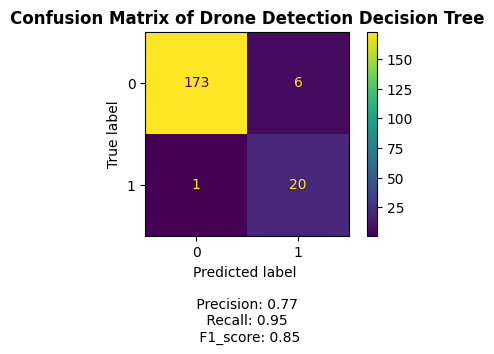

In [8]:
params, metrics = Accuracy(X_train_final, X_test_final, y_train, y_test, threat_ids)

In [9]:
import mlflow

/Users/josh/Documents/Vs Code/NSIN/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
mlflow.set_tracking_uri("http://127.0.0.1:5000/")
mlflow.set_experiment("Drone Detection")

for i, element in enumerate(models):
    model_name = element
    model = models[model_name]
    report = reports[i]

    with mlflow.start_run(run_name=model_name):
        mlflow.log_param('model_name', model_name)
        mlflow.log_metric('accuracy', report['accuracy'])
        mlflow.log_metric('precision', report['weighted avg']['precision'])
        mlflow.log_metric('recall', report['weighted avg']['recall'])
        mlflow.log_metric('f1_score', report['weighted avg']['f1-score'])
    if "XGB" in model_name:
        mlflow.xgboost.log_model(model, model_name)
    else: 
        mlflow.sklearn.log_model(model, model_name)


2026/04/19 12:06:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/19 12:06:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run dt_clf at: http://127.0.0.1:5000/#/experiments/3/runs/2f56eb8adab148f5978ac7faff8a0614
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


2026/04/19 12:06:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/19 12:06:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run xgb_clas at: http://127.0.0.1:5000/#/experiments/3/runs/fcff3288ccbb4e8f96daaf1a165f3847
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


2026/04/19 12:06:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/19 12:06:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run rnd_forest at: http://127.0.0.1:5000/#/experiments/3/runs/80901f3c67114be2ac1f180004161c97
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [11]:
model_name = "drone_detection_model_testing"
model_version = 1
model_uri = f"models:/{model_name}@challenger"

loaded_model = mlflow.sklearn.load_model(model_uri)
y_pred = loaded_model.predict(X_test_final[loaded_model.feature_names_in_])
y_pred[:4]


array([0, 0, 0, 0])

In [12]:
client = mlflow.MlflowClient()
prod_model = 'drone_detection_model'
client.copy_model_version(src_model_uri='models:/drone_detection_model_testing/1', dst_name=prod_model)

Registered model 'drone_detection_model' already exists. Creating a new version of this model...
Copied version '1' of model 'drone_detection_model_testing' to version '5' of model 'drone_detection_model'.


<ModelVersion: aliases=[], creation_timestamp=1776614811424, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1776614811424, metrics=None, model_id=None, name='drone_detection_model', params=None, run_id='', run_link='', source='models:/drone_detection_model_testing/1', status='READY', status_message=None, tags={}, user_id='', version='5', workspace='default'>